



#                                                       **AUSTO MOTOR COMPANY**
---



**Context:**

Austo Motor Company is a leading car manufacturer specializing in SUV, Sedan, and Hatchback models. In its recent board meeting, concerns were raised by the members on the efficiency of the marketing campaign currently being used. The board decides to rope in an analytics professional to improve the existing campaign.

**Objective:**

They want to analyze the data to get a fair idea about the demand of customers which will help them in enhancing their customer experience. Suppose you are a Data Scientist at the company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

# **DATA DESCRIPTION**

*   **Age:** The age of the individual in years.
*   **Gender:** The gender of the individual, categorized as male or female.
*   **Profession:** The occupation or profession of the individual.
*   **Marital_status:** The marital status of the individual, such as     
 married &, single
*   **Education:** The educational qualification of the individual Graduate and  Post Graduate
*   **No_of_Dependents:** The number of dependents (e.g., children, elderly parents) that the individual supports financially.
*   **Personal_loan:** A binary variable indicating whether the individual has taken a personal loan "Yes" or "No"
*   **House_loan:** A binary variable indicating whether the individual has taken a housing loan "Yes" or "No"
*   **Partner_working:** A binary variable indicating whether the individual's partner is employed "Yes" or "No"
*   **Salary:** The individual's salary or income.
*   **Partner_salary:** The salary or income of the individual's partner, if applicable.
*   **Total_salary:** The total combined salary of the individual and their partner (if applicable).
*   **Price:** The price of a product or service.
*   **Make**:  The type of automobile

























# **IMPORTING THE LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Installing Plotly.**

In [ ]:
# !pip install plotly  # Required only if Plotly is not installed (e.g., in local Jupyter)


In [2]:
import plotly.express as px
import plotly.graph_objects as go


# **LOADING DATASET**

## **Importing dataset**

In [3]:
from google.colab import files
uploaded = files.upload()


Saving austo_automobile.csv to austo_automobile.csv


# **DATA OVERVIEW**

**Loading the dataset and then checking the first and last 5 rows of the dataset.**

In [4]:
austo_data = pd.read_csv('austo_automobile.csv') #Loading csv file.
austo_data.head() #fetches firts 5 rows.

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [5]:
#Checks the last 5 rows.
austo_data.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.0,31600,31000,Hatchback


* We can see austo dataset contains information of its customers.
* Gender column has Male and Female customers both.
* Data set also contains customer info like age, marital status, education, profession.
* Data set also contains info related to different types of loans individuals have, for example: personal loan, house loan.
* Dataset also includes individual's partners information such as if their partner is working or not and partners salary.
* Column Total_salary = Salary(individual's salary) + Partner_salary
* We can also observe few of the columns have null values, which we will investigate later.





**Checking the data types of dataset.**

In [6]:
#Checking the data types of the columns.
austo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


* We can observe that there are 8 categorical columns of data type - object and 6 numerical columns of data type - int64(5) and float type(1).



In [7]:
#Checking the shape of the dataset
austo_data.shape

(1581, 14)

Shape of dataframe shows we have 1581 rows and 14 columns.

**Checking statistical summary of the dataset.**

In [8]:
austo_data.describe().T #checking statistical data

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


*   We can clearly observe that min age is 22 and max is 54, while average age is around 31.
* Average number of dependents is around 3 while max is 4.
*   Min salary of an individual is 30000.0 and max is 99300.0 and Average salary of an individual is around 60392.
* The 25th percentile (Q1) for Partner_salary is 0, while the 75th percentile (Q3) is 38,300, shows a large IQR range i.e. 38,300. Since, the difference is significantly large, it indicates the distribution is rightly skewed, and might have outliers either due to presence of NaN values or Partner_salary being 0 due non-working partners.
*   The Average price of a product is approximately 35598.








# **DATA CLEANING**

In [9]:
#cheching columns

col_list= austo_data.columns
print(col_list)

Index(['Age', 'Gender', 'Profession', 'Marital_status', 'Education',
       'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working',
       'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make'],
      dtype='object')


## **Checking all categorical columns to see unique values and counts.**

In [10]:
#cheching categorical columns
catcol_list= ['Gender','Profession','Marital_status','Education','Personal_loan','House_loan','Partner_working','Make']
for col in catcol_list:
    print(f"\n{col}:")
    print(f"Unique values in {col}: {austo_data[col].unique()}")

    print(austo_data[col].value_counts(normalize=False, dropna=False).to_string())


Gender:
Unique values in Gender: ['Male' 'Femal' 'Female' nan 'Femle']
Gender
Male      1199
Female     327
NaN         53
Femal        1
Femle        1

Profession:
Unique values in Profession: ['Business' 'Salaried']
Profession
Salaried    896
Business    685

Marital_status:
Unique values in Marital_status: ['Married' 'Single']
Marital_status
Married    1443
Single      138

Education:
Unique values in Education: ['Post Graduate' 'Graduate']
Education
Post Graduate    985
Graduate         596

Personal_loan:
Unique values in Personal_loan: ['No' 'Yes']
Personal_loan
Yes    792
No     789

House_loan:
Unique values in House_loan: ['No' 'Yes']
House_loan
No     1054
Yes     527

Partner_working:
Unique values in Partner_working: ['Yes' 'No']
Partner_working
Yes    868
No     713

Make:
Unique values in Make: ['SUV' 'Sedan' 'Hatchback']
Make
Sedan        702
Hatchback    582
SUV          297


* We can see that 'Gender' has spelling and NaN value issues: 'Femal',nan ,'Femle'.

## **Checking numerical inconsistencies in categorical columns.**

In [11]:
#checking numerical inconsistencies in categorical columns

for catcol in catcol_list:
    print(f"Unique values in {catcol}: {austo_data[catcol].unique()}")
    print(f"Data types in {catcol}: {[type(val) for val in austo_data[catcol].unique()]}") #list comprehension used.

Unique values in Gender: ['Male' 'Femal' 'Female' nan 'Femle']
Data types in Gender: [<class 'str'>, <class 'str'>, <class 'str'>, <class 'float'>, <class 'str'>]
Unique values in Profession: ['Business' 'Salaried']
Data types in Profession: [<class 'str'>, <class 'str'>]
Unique values in Marital_status: ['Married' 'Single']
Data types in Marital_status: [<class 'str'>, <class 'str'>]
Unique values in Education: ['Post Graduate' 'Graduate']
Data types in Education: [<class 'str'>, <class 'str'>]
Unique values in Personal_loan: ['No' 'Yes']
Data types in Personal_loan: [<class 'str'>, <class 'str'>]
Unique values in House_loan: ['No' 'Yes']
Data types in House_loan: [<class 'str'>, <class 'str'>]
Unique values in Partner_working: ['Yes' 'No']
Data types in Partner_working: [<class 'str'>, <class 'str'>]
Unique values in Make: ['SUV' 'Sedan' 'Hatchback']
Data types in Make: [<class 'str'>, <class 'str'>, <class 'str'>]


* We can observe all the categorical columns has no inconsistencies including spelling mistakes and data type matches with the values, except for 'Gender' column as it contains NaN value, and hence NaN value is shown as float type even though 'Gender' column should have all values of object dtype.

## **Spelling of female is Femal and Femle in the Gender Column which is wrong, hence fixed female spelling using Replace() else it would have given wrong counts.**



In [12]:
austo_data['Gender'] =austo_data['Gender'].replace({'Femal':'Female', 'Femle':'Female'}) #replace() used to replace values.

In [13]:
austo_data.head() #checking again.

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [14]:
austo_data['Gender'].unique() #checking unique values again in Gender column.

array(['Male', 'Female', nan], dtype=object)

* Now spelling issue is fixed.

## **Checking text based inconsistencies in numerical columns.**

In [15]:
#isinstance(x,str)- checks the presence type/class of variable. Here we are checking if its str type.
numcol_list= ['Age','No_of_Dependents','Salary','Partner_salary','Total_salary','Price']
for numcol in numcol_list:
    text_val = [vals for vals in austo_data[numcol].unique() if isinstance(vals,str)] #list comprehension
    if text_val:
      print(f"Inconsistent value in column {numcol}: text value found-{text_val}")
    else:
      print(f"No Text value found in column '{numcol}'")

No Text value found in column 'Age'
No Text value found in column 'No_of_Dependents'
No Text value found in column 'Salary'
No Text value found in column 'Partner_salary'
No Text value found in column 'Total_salary'
No Text value found in column 'Price'


* We can observe all the numerical columns as no text based inconsistencies.

## **Checking number of Null values**

In [16]:
austo_data.isnull().sum()

,0
Age,0
Gender,53
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


* We see null values in Gender (53) and Partner_salary column (106).
* We will further investigate those columns to see what kind of null values it is.
* For categorical data like Gender, only NaN is checked.
* For numeric data like Salary, we also check for inf and -inf.

## **Investigating for NaN, inf or null values in only Gender and Partner_salary columns.**

In [17]:
# Check NaN for both columns
gender_nan = austo_data['Gender'].isna().sum()

# For numeric column (Partner_salary), check NaN, inf, -inf

salary_inf = np.isinf(austo_data['Partner_salary']).sum()

# Check NaN values for Salary
salary_nan = austo_data['Partner_salary'].isna().sum()


print("Partner salary	NaN count:", salary_nan)


print("Gender NaN count:", gender_nan)

print("Partner Salary Inf count:", salary_inf)

Partner salary	NaN count: 106
Gender NaN count: 53
Partner Salary Inf count: 0


* We can observe NaN value for 'Gender' is 53 and for Partner_salary' is 106.
* We no do not have any inf values existing in our dataset.

## **Check if column contains specific bad values like ('Unknown', 'missing', 'N/A','Invalid').**

In [18]:
#Using apply and lamda function to check unexpected values.
austo_data.apply(lambda col: col.isin(['Unknown', 'Missing', 'N/A','Invalid','Null',-1,9999]).sum()) #isin() checks whether the element is present in the given list.

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


* As we can see above no 'Unknown', 'Missing', 'N/A','Invalid',-1 or 9999 values exists in our dataset.


## **Now,checking Blank values in our dataset.**

In [20]:
#Check Blank values in the data set
col_blank_val = (austo_data== '').sum()
print(col_blank_val)

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


* It is clear that no blank values exit in our data set.

## **Checking Duplicates in the data set.**

In [21]:
#duplicated() used to check the duplicates in the dataset.
duplicate_count = austo_data.duplicated().sum()
print("Number of duplicates in the dataset:", duplicate_count)

Number of duplicates in the dataset: 0


* We can observe no duplicates in our data.

## **Treating NaN value in 'Gender' column.**

In [22]:
#mode of 'Gender'
austo_data['Gender'].mode()

,Gender
0,Male


* It is apparent that Male is the most frequently occurring value in the Gender column.
* Hence, we can impute NaN value with mode as for categorical column it is safe to impute with mode values.

In [23]:
# Imputing NaN values in 'Gender' column with the mode
gender_mode = austo_data['Gender'].mode()[0]
austo_data['Gender'] = austo_data['Gender'].fillna(gender_mode)



In [24]:
#Checking if NaN value 'Gender' column successfully treated.
austo_data.isna().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


* It is observable that there is no more NaN values in 'Gender' column.

In [25]:
#Checking the unique values again.
austo_data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [26]:
austo_data.describe().T  #checking gain to further analyse it.

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


* We observe that Partner_salary column , stats shows min =0 and 25%(Q1) = 0, we need to further investigate if the column as actual zero in below 25% data or is it some missing values.

## **Treating missing values in 'Partner_salary' column.**

In [27]:
(austo_data['Partner_salary'] == 0).sum() #checking total number of zeros

np.int64(623)

* There are total of 623 zeros in partner salary column. We have to filter it further based on if partner is working or not.

In [28]:
austo_data[((austo_data['Partner_salary']==0)| (austo_data['Partner_salary'].isna()))& (austo_data['Partner_working'] == 'No')][['Partner_working','Partner_salary']].shape[0]


713

* Total of 713 rows are returned where the column Partner_working = 'No', the Partner_salary = 0, NaN.
* However, let us further investigate if there are any cases where Partner_working = 'Yes' but Partner_salary = 0, NaN.


In [29]:
austo_data[((austo_data['Partner_salary']==0)| (austo_data['Partner_salary'].isna()))& (austo_data['Partner_working'] == 'Yes')][['Partner_working','Partner_salary']]

,Partner_working,Partner_salary
43,Yes,NaN
49,Yes,NaN
59,Yes,NaN
111,Yes,NaN
209,Yes,NaN
284,Yes,NaN
339,Yes,NaN
376,Yes,NaN
424,Yes,NaN
444,Yes,NaN


* This shows that there are 16 values where Partner_working is 'Yes' and Partner_salary is NaN but not 0.


## **Filling NaN value with 0 whereever partner is not working.**

In [30]:
# Filling NaN with 0.
austo_data.loc[(austo_data['Partner_salary'].isna())& (austo_data['Partner_working'] == 'No'),'Partner_salary'] = 0

In [31]:
#Checking if Nan value reduced.
austo_data['Partner_salary'].isna().sum()

np.int64(16)

* We can see out 106 null values only 16 remaining.
* We will further analyse the statistical summary of Partner salary column to see whether to impute remaining values with mean or median depending upon the presence or absence of outliers.

In [32]:
austo_data['Partner_salary'].describe()

,Partner_salary
count,1565.000000
mean,19062.428115
std,19576.735873
min,0.000000
25%,0.000000
50%,25000.000000
75%,38100.000000
max,80500.000000


* 25% of values are 0 but 75% values are 38100, this difference is huge.
* Max is 80500, this suggests that big jump from Q3(75%), indicating potential outliers.
* It is safer to impute the remaining NaN values with median value of 'Partner_salary' column.



## **Imputing remaining NaN values in 'Partner_salary' column with median value.**

In [33]:
#Calculating the median value in 'Partner_salary'.
Partner_salary_median = austo_data['Partner_salary'].median()
print("Median value of 'Partner_salary':", Partner_salary_median)

#Fill NaN value with Median value whereever 'Partner_working' = Yes
austo_data.loc[(austo_data['Partner_salary'].isna())& (austo_data['Partner_working'] == 'Yes'),'Partner_salary'] = Partner_salary_median



Median value of 'Partner_salary': 25000.0


**Checking the null value again.**

In [34]:
austo_data.isnull().sum()

,0
Age,0
Gender,0
Profession,0
Marital_status,0
Education,0
No_of_Dependents,0
Personal_loan,0
House_loan,0
Partner_working,0
Salary,0


* We can clearly see, there are no null values existing in our dataset now.

## **Converting 'Partner_salary' column to int data type from float.**

In [35]:
#checking if 'partner salary' has non-zero decimals.
#lambda dunctions checks if value divided by 1 give decimal value != 0.
decimals = austo_data['Partner_salary'].apply(lambda x: x % 1 != 0).any() #any() checks value on the returned series.
print(f"Column values contains non-zero decimals: {decimals}")


Column values contains non-zero decimals: False


* We can see there are no non-zero decimals.
* It is safe to convert 'Partner_salary' to int datatype.

In [36]:
austo_data['Partner_salary'] = austo_data['Partner_salary'].astype(int)

In [37]:
#Checking the data type to see if conversion succceeded.
austo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int64 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int64(6), object(8)
memory usage: 173.1+ KB


* 'Partner_salary' column is now of int data type.

## **Now, We know 'Partner_salary' had NaN values previously.So,it becomes necessary to verifying if 'total_salary' is equal to 'Salary' + 'Partner_salary'.**

In [38]:
#Verify total salary with calculated salary in the data set.
verify_totalsal = (austo_data['Salary'] + austo_data['Partner_salary'] == austo_data['Total_salary']).all()
print(verify_totalsal)

False


* Since, the output is False that means there is some mismatch in the calculations i.e. the calculated total salary is not equal to the original 'Total_salary'.
* We need to further investigate to know why we have the mismatch.

## **Checking for mismatched rows of total salary column with the calculated salary.**

In [39]:
#Fetching the mismatchg rows of calculated salary and Total_salary
mismatch_rows = austo_data.loc[(austo_data['Salary'] + austo_data['Partner_salary'] != austo_data['Total_salary']),['Salary','Partner_salary','Total_salary']]
print(mismatch_rows,'\n')
mismatch_rows.shape

      Salary  Partner_salary  Total_salary
43     87600           25000         88200
49     90300           25000        170400
59     80600           25000         81000
111    90300           25000        161100
209    53400           25000        123900
284    70500           25000        105800
339    76800           25000        115400
376    79000           25000        117400
424    62000           25000        100700
444    72300           25000        112400
554    41600           25000         70100
654    64700           25000         93200
779    59000           25000         87700
1345   34600           25000         58800
1349   32400           25000         58200
1546   32600           25000         59300 



(16, 3)

* The data indicates that mismatch only exists where we have imputed NaN value with median values where the partner_working = Yes.
* Initially we used median approach as it was safer and most common method.
* However, after verification we can clearly see we need to fill the NaN values with 'Total_salary - Salary' values.
* This approach seems better to maintain the consistency of data.

### **Initially we used median approach as it was safer and most common method.However, after verification we can clearly see we need to fill the NaN values with 'Total_salary - Salary' values.**

In [40]:
#filling Median imputed values to 'Total_salary - Salary' values.
austo_data.loc[(austo_data['Salary'] + austo_data['Partner_salary'] != austo_data['Total_salary']), 'Partner_salary'] = (austo_data['Total_salary']-austo_data['Salary'])

## **Verifying the Total salary again after imputation.**

In [41]:
# verifying the Total salary again after imputation.

verify_totalsal = (austo_data['Salary'] + austo_data['Partner_salary'] == austo_data['Total_salary']).all()
print(verify_totalsal)

True


* The results demonstrates that Salary + Partner_salary = Total_salary now.
* There is no discrepancies in the data now.

# **UNIVARIATE ANALYSIS**

## **Checking distribution of all numerical columns**

**Observations on Age column.**

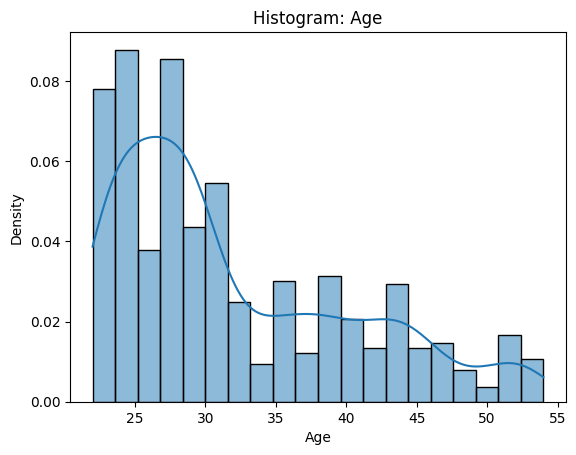

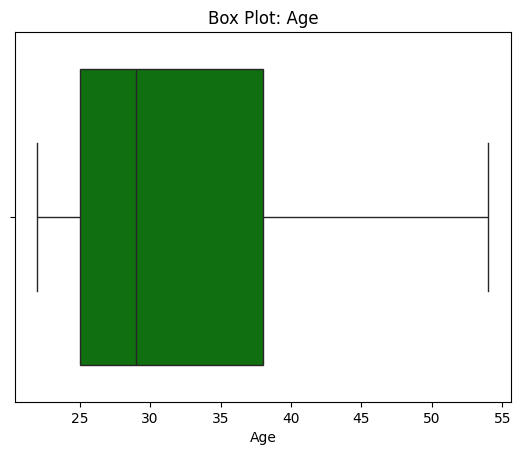

In [42]:
# Creating histogram plot.
plt.title('Histogram: Age')
sns.histplot(data = austo_data, x = 'Age', kde= True, bins= 20, stat = 'density' )
plt.show()

#Creating Box plot graph.
plt.title('Box Plot: Age')
sns.boxplot(data = austo_data, x = 'Age', color = 'green')
plt.show()

* Distribution of data is rightly skewed.
* There are no outliers present as we can see from the box plot.
* Majority of individuals is around the age of 25-30 yrs., ranging max age to
around 55.
* Median age is around 28yrs.


**Observations on No_of_Dependents Column.**


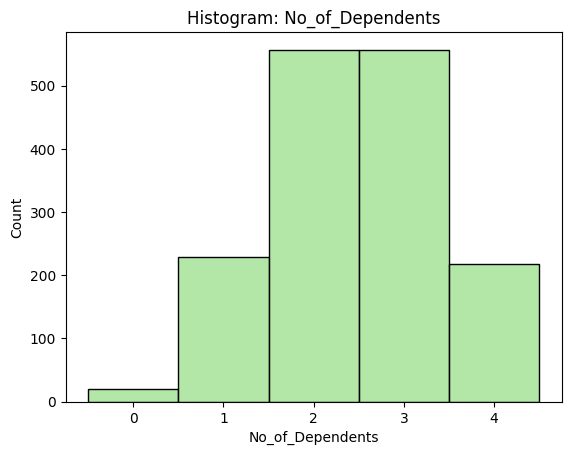

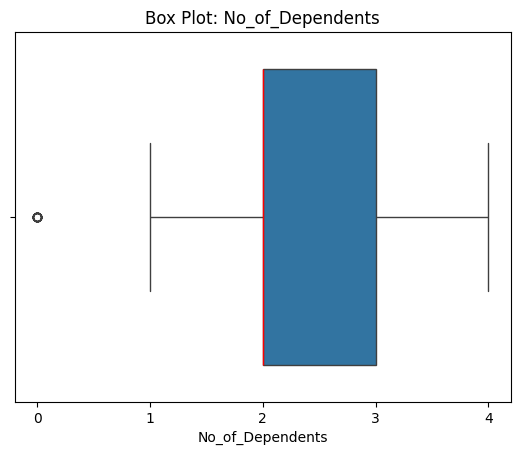

In [43]:
# Creating histogram plot.
plt.title('Histogram: No_of_Dependents')
sns.histplot(data = austo_data, x = 'No_of_Dependents',discrete=True, color = '#98DF8A')
plt.show()

#Creating Box plot graph.
plt.title('Box Plot: No_of_Dependents')
plt.xticks(ticks=[0, 1, 2, 3, 4])
sns.set(style="darkgrid")
sns.boxplot(data = austo_data, x = 'No_of_Dependents',medianprops={'color': 'red', 'linewidth': 1})
plt.show()

* Data has slightly symmetrical distribution.
* Majority of individuals family have numbers of dependents either 2 or 3.
* The box plot marks 0 as an outlier even though statistical summary shows 0 is the min number of dependent while box plot shows 1.
* This is because in the dataset only 20/1581 records have 0 dependents.
* The lower whisker (Q1 - 1.5*IQR) is 0.5, and 1 is the nearest value ≥0.5. This means that 'no dependents' is statistically rare in this dataset.
* 75% of individuals have three number of dependents and maximum number of dependent is 4.

**Observations on Salary column.**

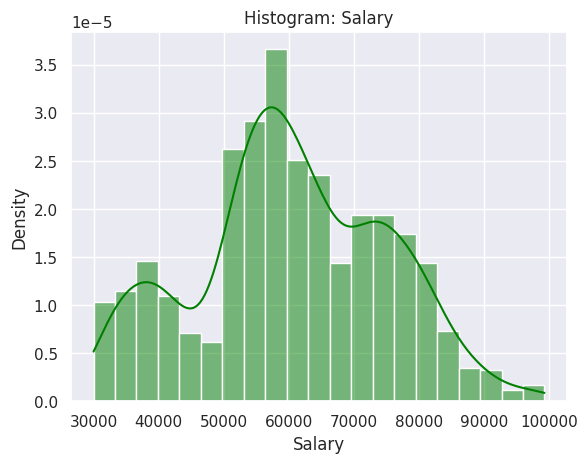

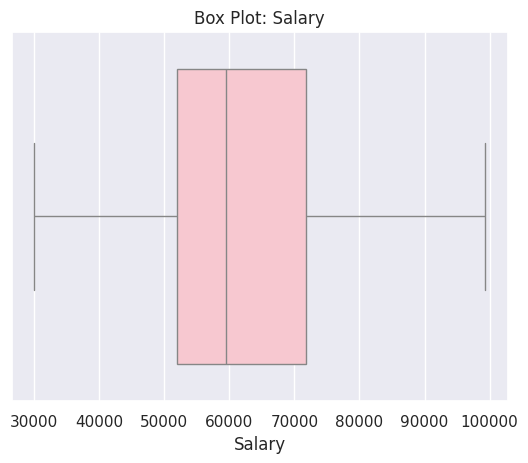

In [44]:
# Creating histogram plot.
plt.title('Histogram: Salary')
sns.histplot(data = austo_data, x = 'Salary', kde= True, stat = 'density',color = 'green')
plt.show()

#Creating Box plot graph.
plt.title('Box Plot: Salary')
sns.set(style="darkgrid")
sns.boxplot(data = austo_data, x = 'Salary',color = 'pink')
plt.show()

* The plot shows the Salary data is normally distributed.
* There are no outliers present for Salary data.
* Since, the median salary is around 60000, we can infer 50% of the salary lies below 60k, whereas the max is around 100000.



**Observations on Partner salary column.**

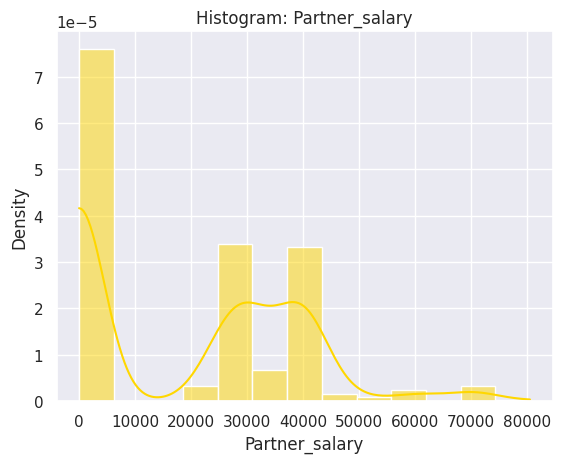

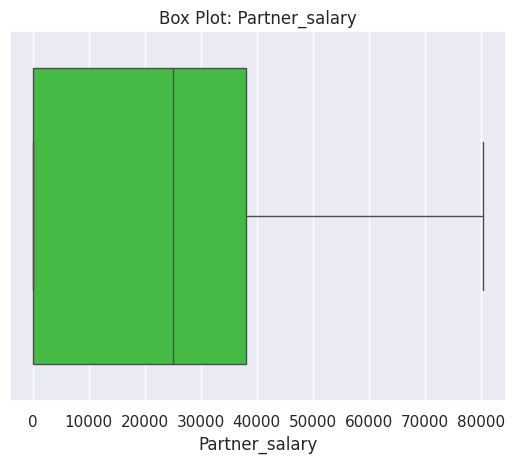

In [45]:
# Creating histogram plot.
plt.title('Histogram: Partner_salary')
sns.histplot(data = austo_data, x = 'Partner_salary', kde= True, stat = 'density',color = 'gold')
plt.show()

#Creating Box plot graph.
plt.title('Box Plot: Partner_salary')
sns.set(style="darkgrid")
sns.boxplot(data = austo_data, x = 'Partner_salary',color = 'limegreen')
plt.show()

* Partner salary data looks right skewed.
* There are no outliers present.
* The minimum value is equal to the Q1 (25th percentile)= 0, so the lower whisker is absent here.
* Minimum Partner salary is 0 due to partner not working, while max Partner salary is slightly above 80k.

**Observations on Total salary column.**

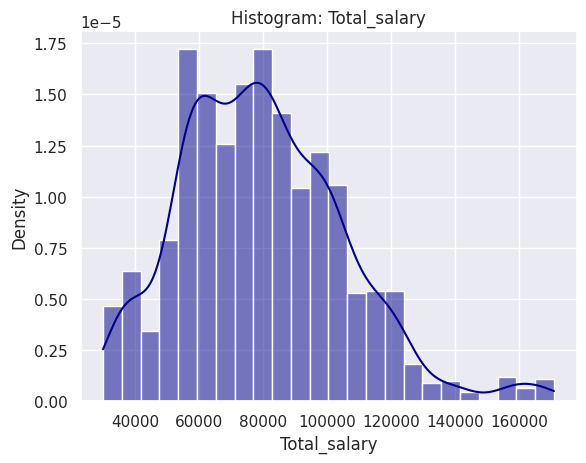

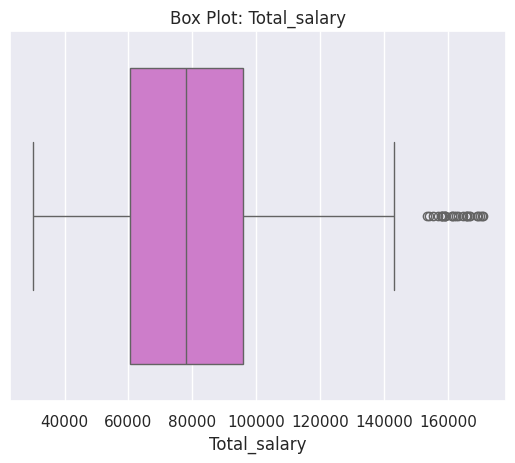

In [46]:
# Creating histogram plot.
plt.title('Histogram: Total_salary')
sns.histplot(data = austo_data, x = 'Total_salary', kde= True, stat = 'density',color = 'darkblue')
plt.show()

#Creating Box plot graph.
plt.title('Box Plot: Total_salary')
sns.set(style="darkgrid")
sns.boxplot(data = austo_data, x = 'Total_salary',color = 'orchid')
plt.show()

* Distribution is slightly skewed towards the right side.
* We can observe there are presence of outliers above upper whisker, indicating some of the customers have significantly higher total salary.
* Many of the customers have total salary in between 60k to 90k.

**Observations on Price column.**

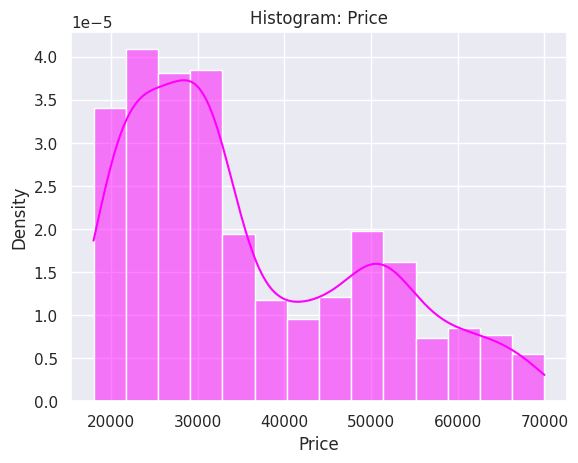

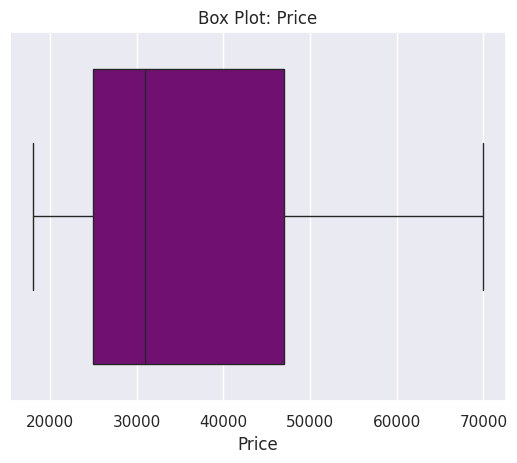

In [47]:
# Creating histogram plot.
plt.title('Histogram: Price')
sns.histplot(data = austo_data, x = 'Price', kde= True, stat = 'density',color = 'magenta')
plt.show()

#Creating Box plot graph.
plt.title('Box Plot: Price')
sns.set(style="darkgrid")
sns.boxplot(data = austo_data, x = 'Price',color = 'purple')
plt.show()

* Price data distributions is rightly skewed.
* There are no outliers present.
* Minimum price of product is 18000 and maximum is 70k.

## **Outliers Detection and Treatment.**

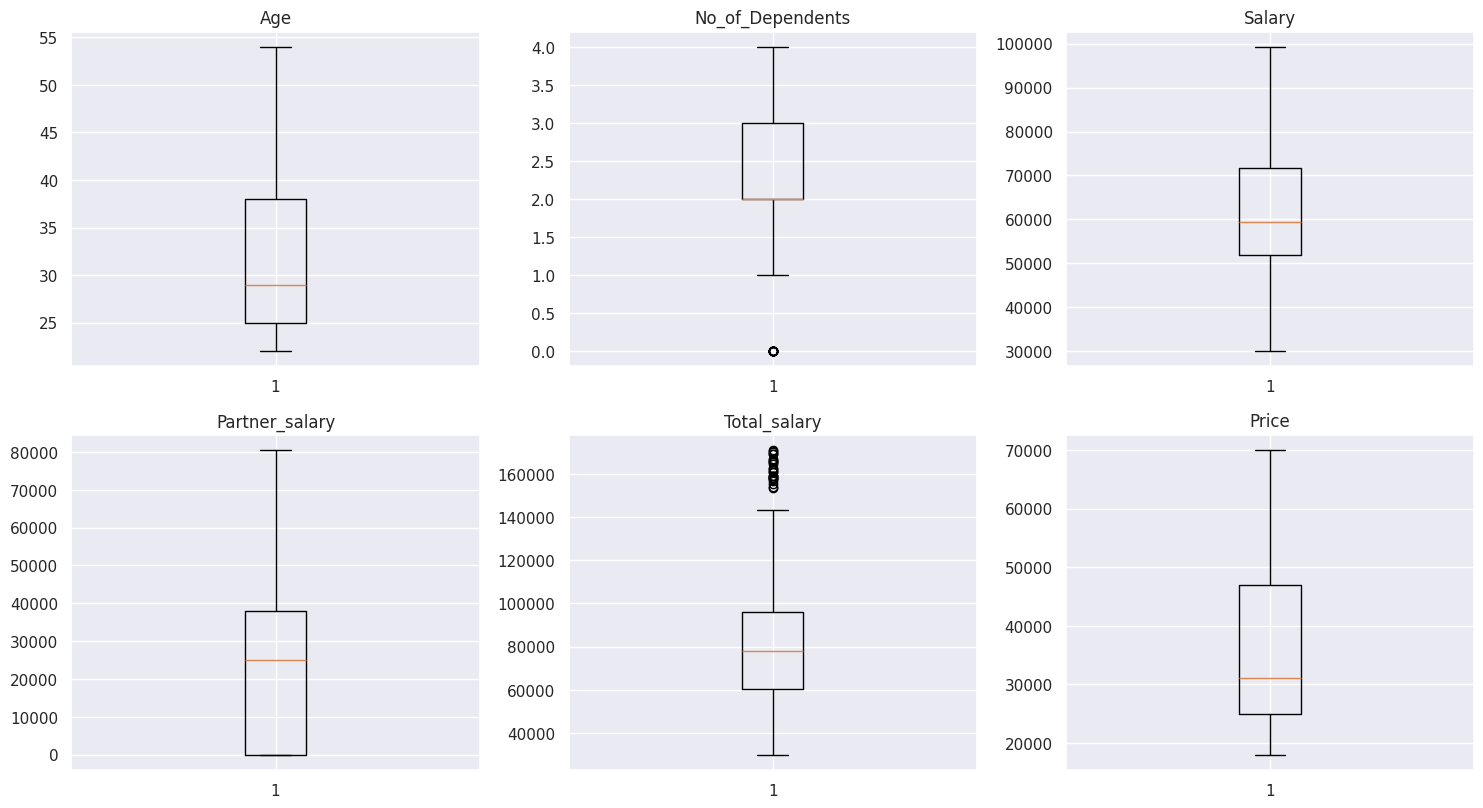

In [48]:
#selecting numerical columns of data and adding their names to list
#numcol_list=['Age','No_of_Dependents','Total_salary','Price','Salary','Partner_salary'] is already defined list above cells.
plt.figure(figsize=(15,12))

for i, var in enumerate(numcol_list): #for loop to loop over each variable in the numcol_list.
  plt.subplot(3,3,i + 1)
  plt.boxplot(austo_data[var],whis=1.5) #Using box plot to detect outliers.
  plt.tight_layout()
  plt.title(var)

* We can infer from the plots that outliers are present only in No_of_Dependents, Total_salary columns.
* Outlier present in No_of_Dependents is at 0. Since having no dependent is a valid category. Hence, we have decided not to treat this value as an outlier.
* Outliers in Total_salary column indicates that some of the customers have significantly higher total salary due to high income individuals or their partners as compared to the rest of the dataset. Removing those values may distort the original data distribution leading to misleading conclusions.Therefore, we will retain these value to preserve the integrity of our dataset.


## **Checking distribution of all categorical columns**

**Observations on Gender column.**

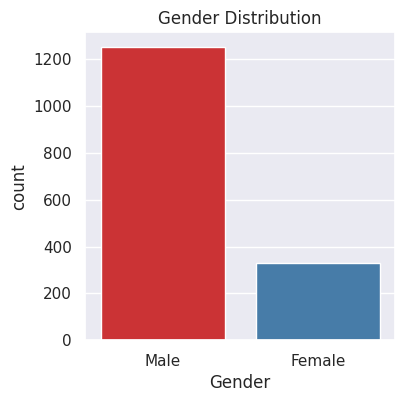

In [49]:
#plotting countplot.
plt.figure(figsize=(4,4))
plt.title('Gender Distribution')
sns.countplot(data=austo_data,x='Gender',hue='Gender',palette='Set1',legend=False)
plt.show()



* It is evident from the plot that there are more number of males as compared to females.
* Number of males are 1252 while females are 329.

**Observations on Profession column.**

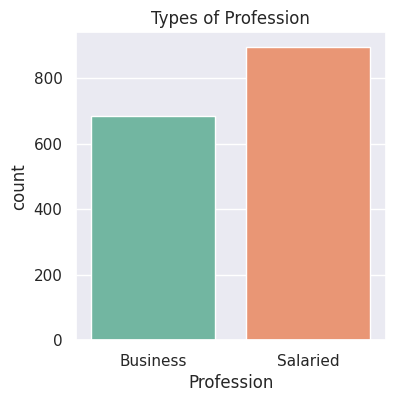

In [50]:
#plotting countplot.
plt.figure(figsize=(4,4))
plt.title('Types of Profession')
sns.countplot(data=austo_data,x='Profession',hue='Profession',palette='Set2',legend=False)
plt.show()


* Bar plot shows there as more number of salaried individuals than business professionals.
* Total number of salaried members are 896 and business professional are 685.


**Observations on Marital_status column.**

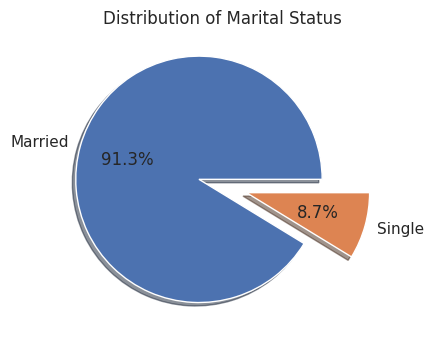

In [51]:
#counts of unique values in marital status column
marital_counts = austo_data['Marital_status'].value_counts()

#Plot pie chart
plt.figure(figsize=(4, 4))
#autopct='%1.1f%%': show percentages on the pie with 1 decimal place.
plt.pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%',shadow = True,explode= (0.2, 0.2)) #marital_counts.index will give the category names
plt.title('Distribution of Marital Status')
plt.show()



* Nearly 91% of the individuals in the dataset are classified as married.
* Approximately 9% of individuals are single in the given dataset.
* Thus, married individuals are more as compared to single individuals.

**Observations on Education  column.**

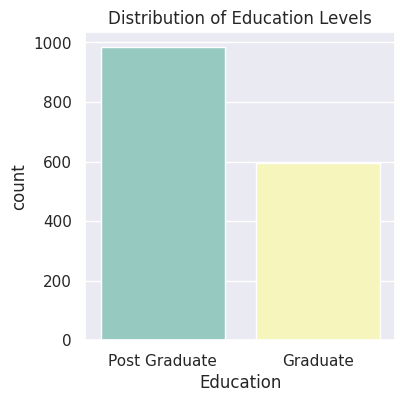

In [52]:
#plotting countplot.
plt.figure(figsize=(4,4))
plt.title('Distribution of Education Levels')
sns.countplot(data=austo_data,x='Education',hue='Education',palette='Set3',legend=False)
plt.show()

* Number of individuals having post graduate level education outnumbered individuals with graduate level education.
* Number of Post Graduate: 985
* Number of Graduate: 596

**Observations on Personal_loan column.**

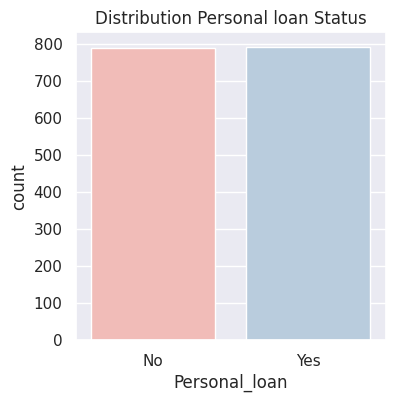

In [53]:
#plotting countplot.
plt.figure(figsize=(4,4))
plt.title('Distribution Personal loan Status')
sns.countplot(data=austo_data,x='Personal_loan',hue='Personal_loan',palette='Pastel1',legend=False)
plt.show()

* It indicates there is a balanced distribution between individuals who have taken loan and who have not.
* Number of individuals who have taken loan are 792 while who have not are 789.

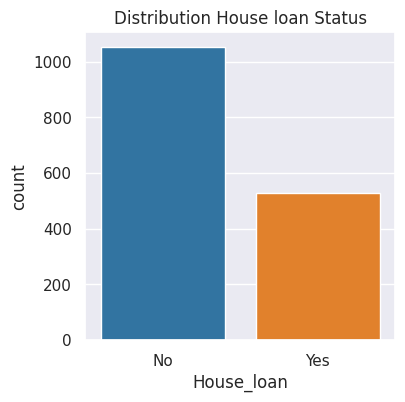

In [54]:
#plotting countplot.
plt.figure(figsize=(4,4))
plt.title('Distribution House loan Status')
sns.countplot(data=austo_data,x='House_loan',hue='House_loan',palette='tab10',legend=False)
plt.show()

* The number of individuals who have not taken house loan outnumbered the individuals who have taken.
* Number of individuals with house loan: 527
* Number of individuals without house loan: 1054

**Observations on Partner_working column.**

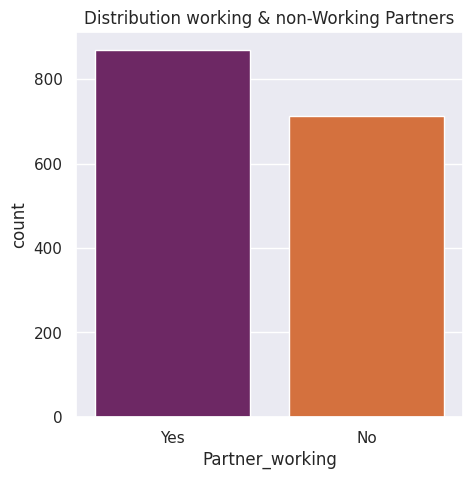

In [55]:
#plotting countplot.
plt.figure(figsize=(5,5))
plt.title('Distribution working & non-Working Partners')
sns.countplot(data=austo_data,x='Partner_working',hue='Partner_working',palette='inferno',legend=False)
plt.show()

* There is slightly balanced distribution. However, there is still notable difference between working i.e. 868 individuals and non-working i.e. 713 individuals, suggesting most households rely on single income.
* Majority of individuals in the dataset have partners who are employed indicating dual-income house hold.


**Observations on Make column.**

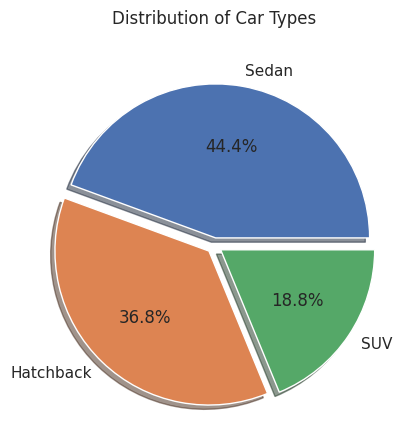

In [56]:
#counts of unique values in Make column
car_type = austo_data['Make'].value_counts()

#Plot pie chart
plt.figure(figsize=(5,5))
#autopct='%1.1f%%': show percentages on the pie with 1 decimal place.
plt.pie(car_type, labels=car_type.index, autopct='%1.1f%%',shadow = True,explode= (0.05, 0.05, 0.05)) #car_type.index will give the category names.
plt.title('Distribution of Car Types\n')
plt.show()

* Nearly 44% of customers prefer Sedan cars over other car type, making it more popular among customers.
* Approximately 37% customers prefer Hatchback type car while around 19% of customers prefer SUVs.






# **BIVARIATE ANALYSIS**

## **We will now find correlation between all numerical columns using heat map.**

**Utilising Correlation Heat map to find the correlation between all the numerical columns given in dataset.**

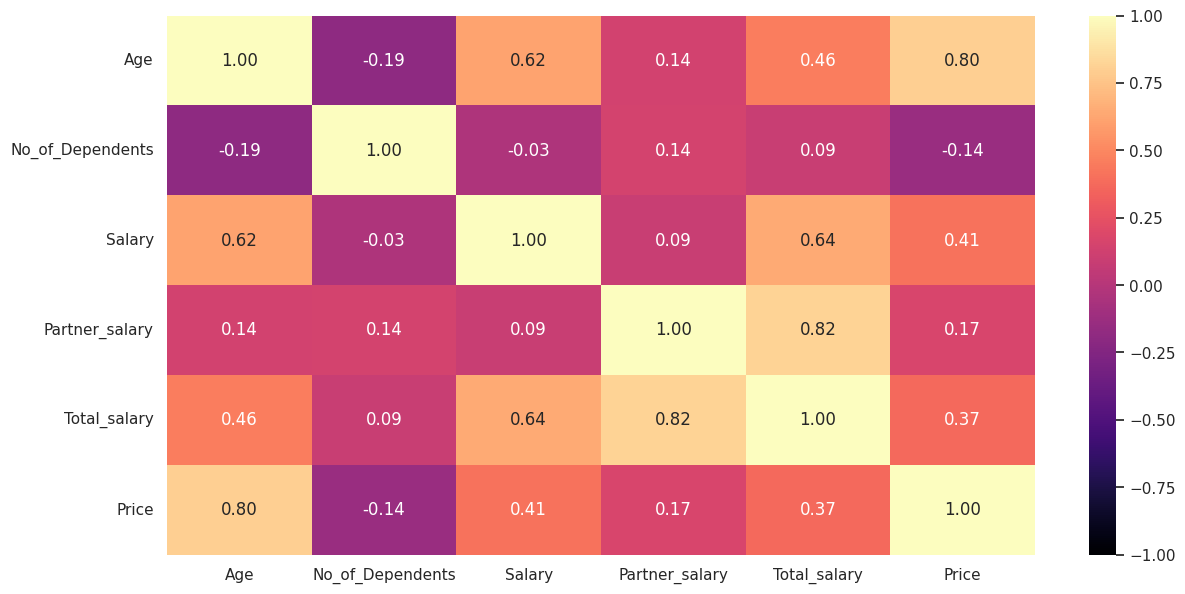

In [57]:
#numcol_list=['Age','No_of_Dependents','Total_salary','Price','Salary','Partner_salary'] is already defined list in above cells.

# Check for correlation among numerical variables
corr = austo_data[numcol_list].corr()

# plot the heatmap

plt.figure(figsize=(14, 7))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="magma")
plt.show()

* We can infer from the heat map that Age and Price has strong positive correlation(r = 0.80), indicating that older customers might spend more on high priced cars in comparison to younger customers.
* There is moderate positive correlation (r = 0.64) between Salary and Partner salary whereas Partner salary and Total salary have strong positive correlation (r = 0.82). This suggests that individuals and their Partners  with high salaries contributes to high total income of the family.
* A moderate positive correlation (r = 0.62) exist between Age and Salary. This reveals that older individuals tend to have high salary due to more experience in their career.
* There appears to be a weak positive correlation between Partner salary and age (r = 0.14), indicating that older customers may have partners with high income.
* There is also weak positive correlation between Total Salary and Price (r = 0.37) suggesting as the total income increases, customers may spend more on the high priced cars.
* There is a weak positive correlation exist between No_of_Dependents and Total salary (r= 0.09) indicating that households with more dependents do not have significantly higher salaries.
* The correlation coefficient suggests that there is a weak negative correlation exist between No_of_Dependents and Age (r = -0.19) indicating that as the age increasing, the No_of_Dependents decreases possibly due to children growing up or living independently.
* There is also weak negative correlation between No_of_Dependents and Salary ( r = -0.03) indicating that no. of dependents does not significantly affect salary
* A weak negative correlation exist between No_of_Dependents and Price ( r = -0.14) suggesting that as the number of dependents increases, the price tends to decrease slightly.


### **Let's analyse the relation between Age and Price.**

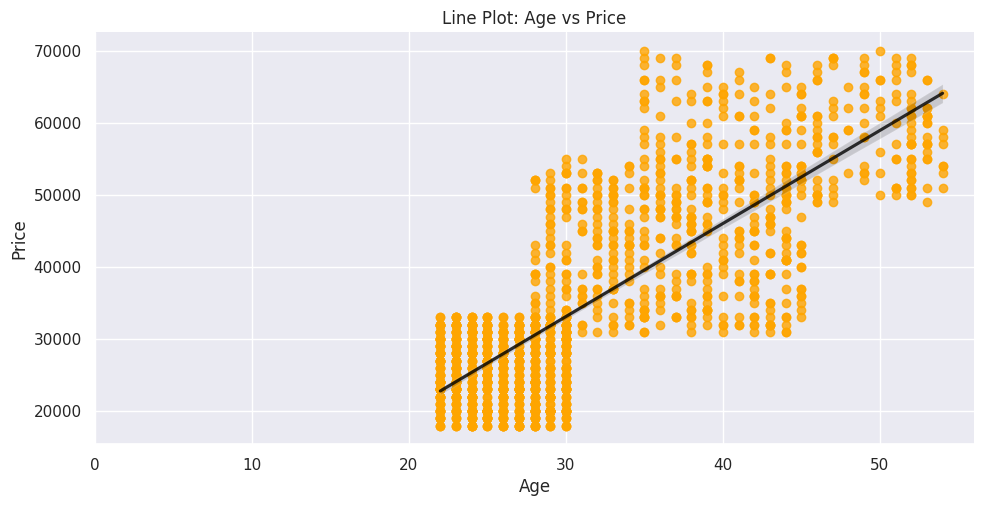

In [58]:
#plot line plot to analyse the trend.
sns.set(style="darkgrid")
sns.lmplot(data=austo_data,x='Age',y='Price',height=5,aspect=2,ci=95,line_kws={'color': 'black','alpha': 0.8},scatter_kws={'color': 'orange'})
plt.title('Line Plot: Age vs Price')
plt.xlim(0,56)
plt.show()

* We can clearly observe the increasing trend showing as the Age increases, individuals willing to spend more.
* This relation reveals strong positive correlation.

### **Let's analyse the relation between Salary, Partner_Salary and Total_salary.**

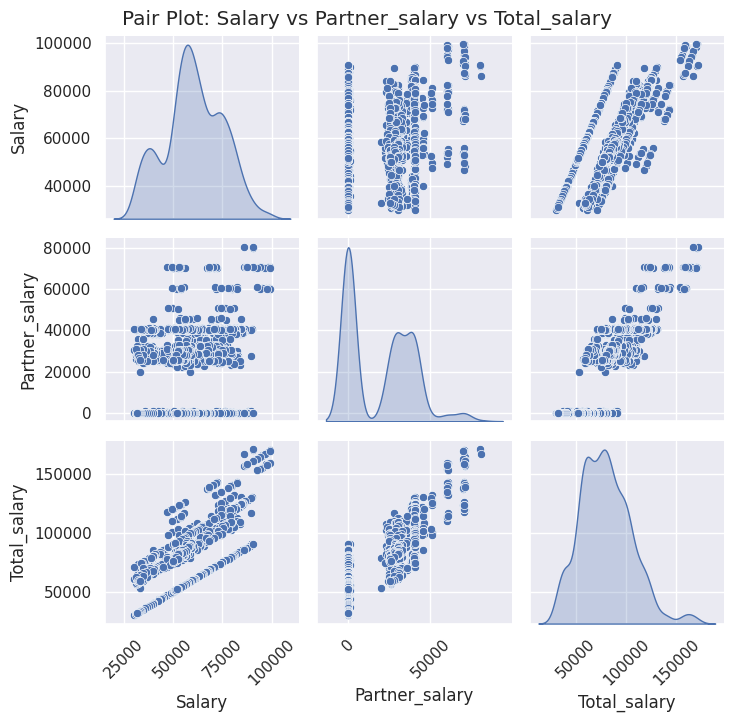

In [59]:
#List of only salary related columns.
Salcol_list = ['Salary','Partner_salary', 'Total_salary']

#pair plot
g1 = sns.pairplot(data=austo_data[Salcol_list],diag_kind="kde")
g1.fig.suptitle('Pair Plot: Salary vs Partner_salary vs Total_salary', y=0.96)
for ax in g1.axes.flat:
   #set rotation for x-axis ticks labels
  for label in ax.get_xticklabels():
    label.set_rotation(45)
plt.tight_layout()
plt.show()

* There is an increasing linear relationship between total salary and salary.
* Plot reveals that there is positive correlation between Salary and Total salary suggesting that if salary increases, total salary also increases.
* Similar trend is also seen in Total salary and partner salary as well suggesting positive correlation.




### **Observing relation between Salary and Age.**

In [60]:
# Plotting individual customer salaries across age.
fig = px.scatter(data_frame=austo_data, x="Age", y="Salary", title="Raw Data of Salary vs Age",color_discrete_sequence=['magenta'])
# title in the centre
fig.update_layout(title={'x': 0.5, 'y': 0.86})
fig.show()

* Plot reveals trend between Age and Salary, youngest customer has salary around 60k while oldest customer's salary is around 94k.
* We can observe the trend that average salary is slightly higher for group having age 26 (80.3k).
* However, there is a decreasing trend in average salary after age of 26, this could be due to individuals might be focusing on higher education or career change.
* Again an increasing trend is observed for age group of 35+ (57k-70k), and 45+ (72k-82k), this might be due to their successful career growth, hence their salary tends to be at higher end.
* Plateaus in the plot suggest the change in job market or industry demands.
* This data is useful when strategizing for pricing and manufacturing premium car models based on age groups, as age above 30 may be willing to afford more high end cars.

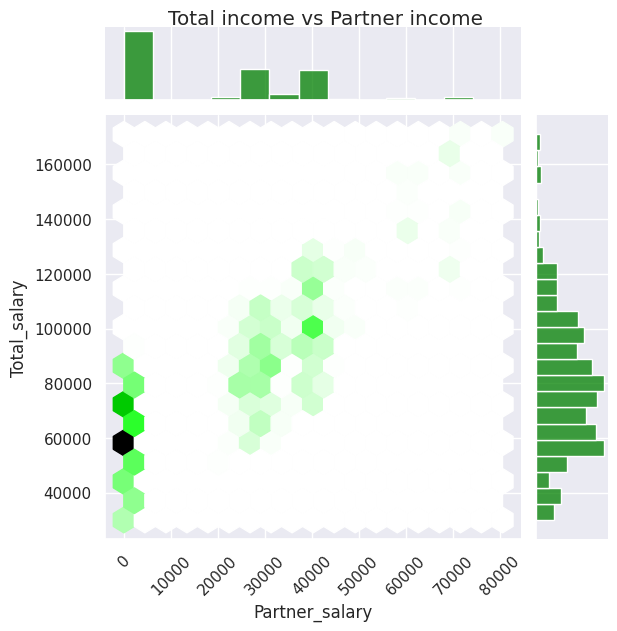

In [61]:
#join plot
g2= sns.jointplot(data=austo_data,y="Total_salary",x="Partner_salary",kind="hex",color='green')
g2.fig.suptitle('Total income vs Partner income', y=1)
#acess the main joint plot axis.
ax = g2.ax_joint
   #set rotation for x-axis ticks labels
for label in ax.get_xticklabels():
    label.set_rotation(45)
plt.show()


* Hex bins suggests diagonal upward trend where partner salary is 20k to total salary at 160k.
* This suggests higher partner income leads to higher total income of household.
* A large sections shows partner income = 0 but total income corresponding to it range from 30k to approximately 100k, indicating households with single income.
* Dual-income household is most prevalent among the groups as partner income range from 30k-40k, there total income range from 90k-130k.
* This data is useful when targeting high dual-income income households for premium car models, as they may be willing to afford more high end cars.



## **Now we will analyse numerical vs categorical columns as it tells us how categories are impact numerics metricies.**

### **Observations on Gender and Price columns to see how prices are varies based on gender segregation.**

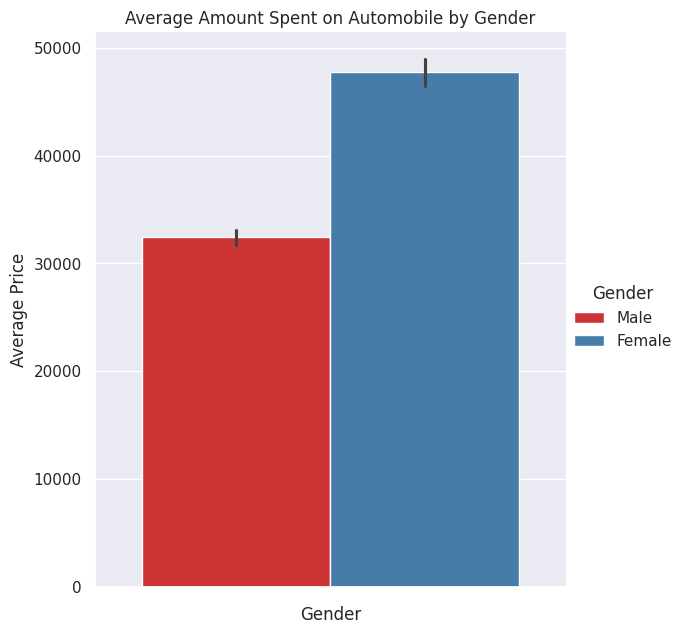

In [62]:
#Creating Bar plot graph.
sns.catplot(data=austo_data,y='Price', hue='Gender',kind='bar',palette='Set1',height=6, aspect=1)
plt.title('Average Amount Spent on Automobile by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Price')
plt.show()



In [63]:
austo_data.groupby('Gender')['Price'].agg(['mean', 'median', 'sum','count']).reset_index()




,Gender,mean,median,sum,count
0,Female,47705.167173,49000.0,15695000,329
1,Male,32416.134185,29000.0,40585000,1252


* Average amount spent on automobile is slightly higher for Female customers as compared to Males.
* Average Price range for car for females is around 48k while for males it is around 32k.
* Median purchase price for males is 29k while for female is 49k.
* Total amount spent to purchase an automobile by female is 15695000 and for males is 40585000.
* Thus, we can conclude that female tend to spend more on automobiles than males.

### **Observations on Partner_working and Total_salary columns to see how partner salary affects total income.**

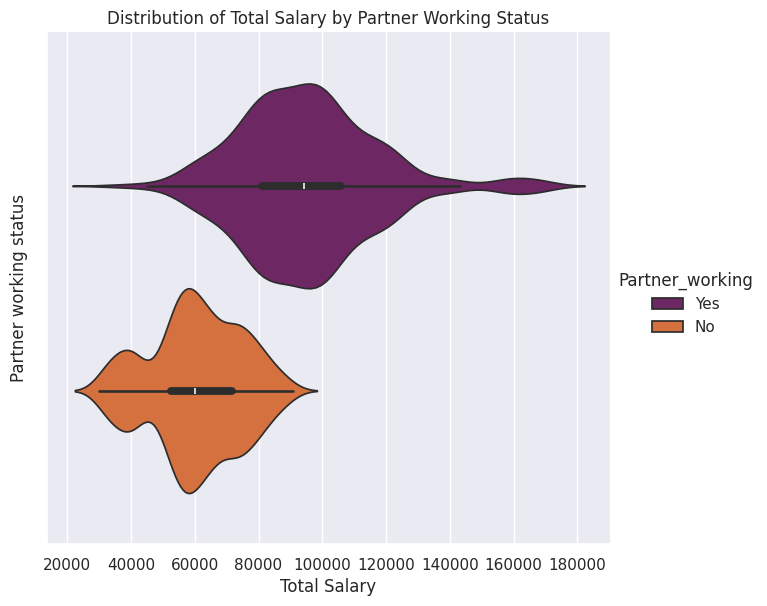

In [64]:
#Creating Violin plot.
sns.catplot(data=austo_data,x='Total_salary', hue='Partner_working',kind='violin',palette='inferno',height=6, aspect=1)
plt.title('Distribution of Total Salary by Partner Working Status')
plt.ylabel('Partner working status')
plt.xlabel('Total Salary')
plt.show()

In [65]:
#Average Total salary distribution based on partner working status
austo_data.groupby("Partner_working")["Total_salary"].mean().reset_index(name='total salary')

,Partner_working,total salary
0,No,60527.208976
1,Yes,95314.285714


* Plot reveals that total income of a household is affected by the working status of the Partner.
* Total salary is on higher end if the partner is working.
* Average total salary of working partner is around 95k.
* Average total salary of non-working partner is around 60k.

### **Let's now observe Price vs Personal_loan columns in order to analyse the amount of money spent on purchasing automobiles by individuals who took a personal loan.**


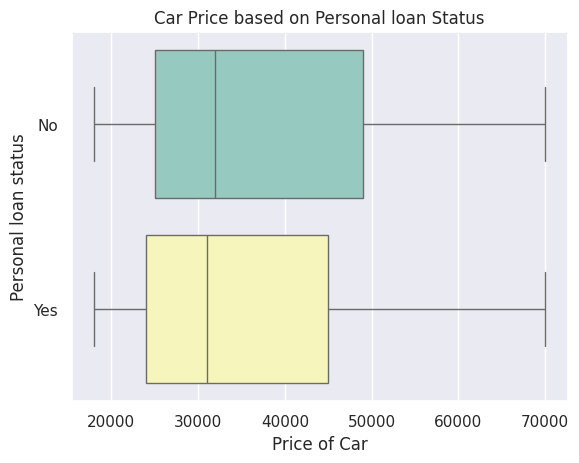

In [66]:
#Creating box plot.
sns.boxplot(data=austo_data,x='Price',y= 'Personal_loan',hue='Personal_loan',palette='Set3')
plt.title('Car Price based on Personal loan Status')
plt.ylabel('Personal loan status')
plt.xlabel('Price of Car')
plt.show()

In [67]:
#finding individuals with a personal loan and calculating average, and sum price they are likely to spend.
austo_data.groupby("Personal_loan")["Price"].agg(['mean','median','sum','count']).reset_index()

,Personal_loan,mean,median,sum,count
0,No,36742.712294,32000.0,28990000,789
1,Yes,34457.070707,31000.0,27290000,792


* The boxplot suggests that individuals who took personal loan tend to spend slightly less on automobiles then those who took loan.
* Average price for people having no personal loan is approximately 37k, while for those with loan is around 34k, indicating non-loan buyers spend more per transaction.
* Total amount spent by 792 individuals who took personal loan to purchase automobile is 27290000, while 789 individuals without loan is 28990000.
* Even though customers without loan were less in number, their total spent is still nearly equal.
* This indicates person without loan spends more money on an average than those with loan, also person without loan spent more per person than those with loan.
* Thus, we can say, individuals without personal loans are purchasing more expensive cars as compared to those with loans, suggesting that people prioritise spending loan amount on important things than luxury.



### **Observations on Profession and Salary columns to analyse how different professions affect income.**

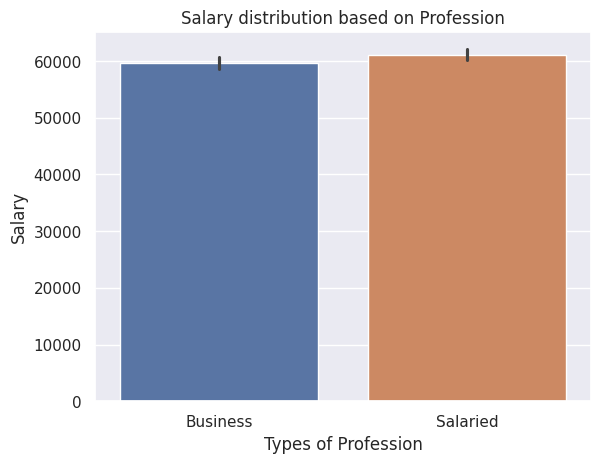

In [68]:
#Creating bar plot.
sns.barplot(data=austo_data, x="Profession", y="Salary", hue = 'Profession')
plt.title('Salary distribution based on Profession')
plt.xlabel('Types of Profession')
plt.ylabel('Salary')
plt.show()


In [69]:
#grouping individuals based on their profession and calculating their average and total earning.
austo_data.groupby("Profession")["Salary"].agg(['mean','sum','count']).reset_index()

,Profession,mean,sum,count
0,Business,59578.978102,40811600,685
1,Salaried,61013.950893,54668500,896


* Plot illustrates that Salaries individuals have slightly higher income than business professionals.
* Mean salary of individuals is around 61k which is slightly higher than individuals with business.
* Total salary of salaried professionals is 54668500 while for business professional is 40811600.
* Thus, we can infer salaried person earns more than business professionals, this could be due to salaried person has fixed earning while income from business is fluctuating based on market status.

### **Observations on Make and Total_salary column in order to understand how total salary affect the purchase of different car model.**

In [70]:
# Violin plot
fig2 = px.violin(austo_data, x="Make", y="Total_salary", title = 'Total Salary distribution as per Car models ', color="Make")
fig2.update_layout(title={'x': 0.5, 'y' : 0.885}, width = 800, height = 600, legend = dict(orientation="v", yanchor="top", y=1, xanchor="right", x=1.02))
fig2.show()

In [71]:
# Average house hold income by car model.
austo_data.groupby("Make")["Total_salary"].mean().reset_index(name='Total salary')

,Make,Total salary
0,Hatchback,71018.041237
1,SUV,96591.582492
2,Sedan,79584.757835


* The violin plot represents that customers having lower total salary prefer to buy Hatch back and similarly customers which moderate household income prefer Sedan, while wealthiest customer prefer SUVs.  
* The customers who prefer Sedan have average income around 79k, and customers who prefer Hatchback have an average household income around 71k while Customers who prefers SUV have average total income around 96k.
* Thus, SUVs are more popular among wealthier customers as a it shows status of luxury symbol.

### **Observations on Make and No_of_Dependents columns to see if larger family needs bigger car.**

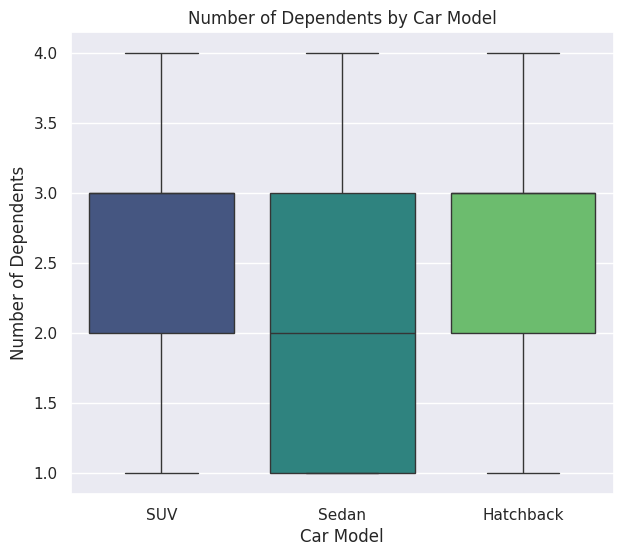

In [72]:
# Boxplot of dependents by car model.
plt.figure(figsize=(7, 6))
sns.boxplot(data=austo_data, x="Make", y= "No_of_Dependents", hue = "Make", palette="viridis", showfliers = False,legend=False)
plt.title("Number of Dependents by Car Model")
plt.xlabel("Car Model")
plt.ylabel("Number of Dependents")
plt.show()

In [73]:
# Calculate average number of dependents per car model
austo_data.groupby("Make")["No_of_Dependents"].agg(["mean", "median", "count"]).reset_index()

,Make,mean,median,count
0,Hatchback,2.778351,3.0,582
1,SUV,2.609428,3.0,297
2,Sedan,2.128205,2.0,702


* As per the plot we can see Sedan users have fewer dependents as compared SUV and Hatchback owners.
* Median no. of dependent for Hatchback and SUV is 3 while for Sedan is 2.
* However, count-wise Sedan is preferred more over other car models as it might caters to smaller household, SUVs are preferred by mid-size household while Hatchback is preferred by larger house hold due to affordability and lower income correlation.
* Thus, we can say that larger families mostly prefer smaller cars due to affordability outweighing the need for larger car space.

### **Observations on Make and Price columns to see how car models are priced.**

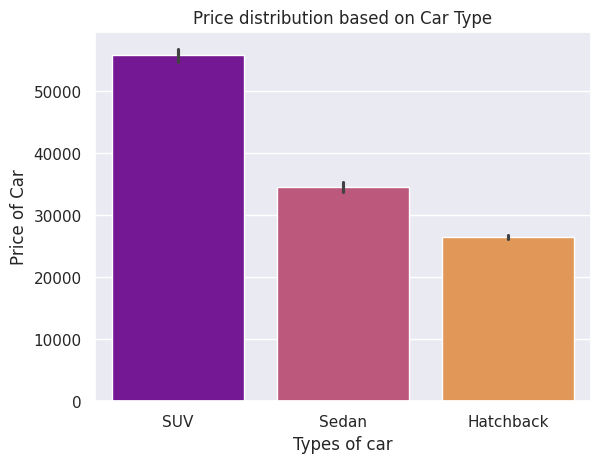

In [74]:
#Creating bar plot.
sns.barplot(data=austo_data, x="Make", y="Price", hue = 'Make', palette='plasma')
plt.title('Price distribution based on Car Type')
plt.xlabel('Types of car')
plt.ylabel('Price of Car')
plt.show()


In [75]:
# Average price of car by car type.
austo_data.groupby("Make")["Price"].mean().reset_index(name='Price')

,Make,Price
0,Hatchback,26474.226804
1,SUV,55824.915825
2,Sedan,34603.988604


* Bar plot shows that SUV car model is most expensive having average price approximately at 55k.
* Sedan car model have the mid price range having average price around 34k , and it is moderately expensive.
* Hatchback seemed to be the cheapest car among others as its average price is around 26k.
* Thus, Hatchback is most affordable, and may be preferred by low household income family, or family's with more number of dependents.


### **Observations on House_loan and Price columns to analyse how home loan status affects the purchase price.**

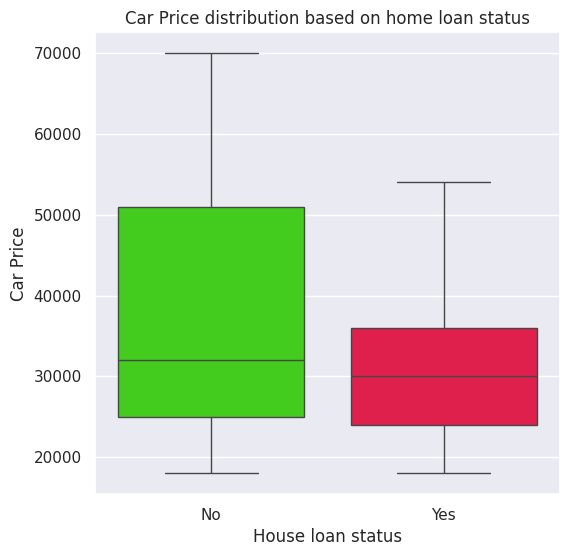

In [76]:
# Boxplot of Price by home loan status.
plt.figure(figsize=(6, 6))
sns.boxplot(data=austo_data, x="House_loan", y= "Price", hue = "House_loan", palette="prism", showfliers = False,legend=False)
plt.title("Car Price distribution based on home loan status")
plt.xlabel("House loan status")
plt.ylabel("Car Price")
plt.show()

In [77]:
#Grouping people who has loans based on the purchase price.
austo_data.groupby("House_loan")["Price"].agg(['mean','count']).reset_index()

,House_loan,mean,count
0,No,37707.779886,1054
1,Yes,31377.609108,527


* The box plot reveals that median purchase price of car for people without house loan is more than people with house loan.
* There are total of 1054 individuals who purchased cars and have no house loan.
* There are 527 individuals who have purchased car and have house loan.
* Average price spent by people with loan is around 37k and without loan is around 31k.
* This indicates that people without loan tend to spend more on car as people with home loan may prioritise mortgage payment than spending on buying a car.
* Therefore, we can conclude that customers home loan status affects the purchase price of cars.

### **Observations on Gender and Salary to determine if individuals earning less or more based on gender.**

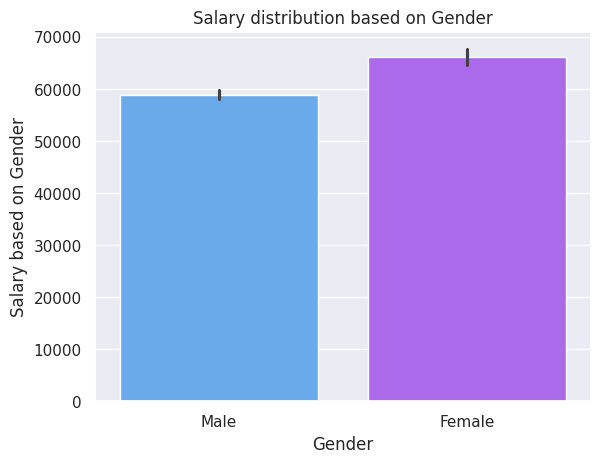

In [78]:
#Creating bar plot.
sns.barplot(data=austo_data, y="Salary", x="Gender", hue = 'Gender', palette='cool')
plt.title('Salary distribution based on Gender')
plt.xlabel('Gender')
plt.ylabel('Salary based on Gender')
plt.show()

In [79]:
#Average Salary based on gender.
austo_data.groupby("Gender")["Salary"].mean().reset_index(name='Salary')

,Gender,Salary
0,Female,66194.528875
1,Male,58867.492013


* The data plot reveals females salary is more than males.
* Average salary of Female is around 66k while for males is around 58k.
* Thus, we can say that females earn more than males, indicating that they can afford cars and its premium models.

### **Observations on Salary and Education columns to determine if education level influence income.**

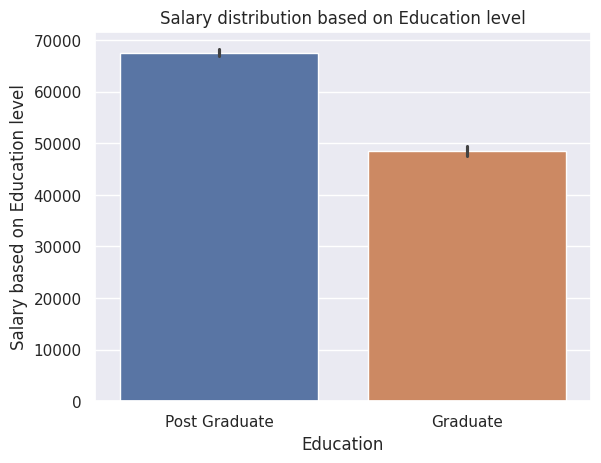

In [80]:
#Creating bar plot.
sns.barplot(data=austo_data, y="Salary", x="Education", hue = 'Education', palette='deep')
plt.title('Salary distribution based on Education level')
plt.xlabel('Education')
plt.ylabel('Salary based on Education level')
plt.show()

In [81]:
#Average Salary based on education.
austo_data.groupby("Education")["Salary"].mean().reset_index(name='Salary')

,Education,Salary
0,Graduate,48506.040268
1,Post Graduate,67584.263959


* The data plot reveals post graduates salary is more than graduates.
* Average salary of post graduates is around 67k while for graduates is around 48k.
* Thus, we can say that post graduates earn more than graduates, indicating that they can afford cars and its premium models.

### **Observations on Gender and Age column to determine age distributionn based on gender.**

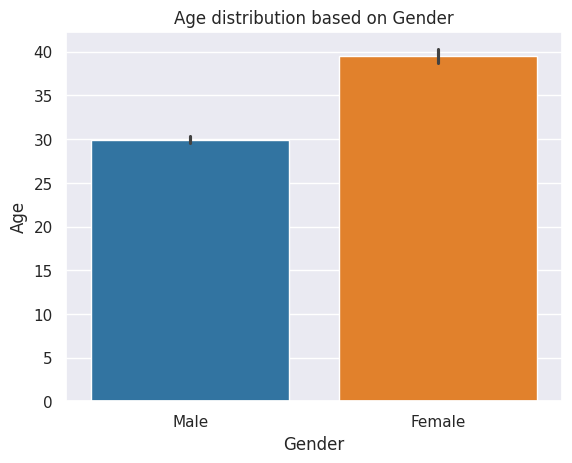

In [82]:
#Creating bar plot.
sns.barplot(data=austo_data, y="Age", x="Gender", hue = 'Gender', palette='tab10')
plt.title('Age distribution based on Gender')
plt.xlabel('Gender')
plt.ylabel('Age')
plt.show()

In [83]:
#Average age based on gender.
austo_data.groupby("Gender")["Age"].mean().reset_index(name='Age')

,Gender,Age
0,Female,39.525836
1,Male,29.924121


* The bar plot suggests that the max age of females is around 39 whereas for males is 29.  
* Average age of females is 39.52 and males is 29.92.
* Females customers are 10 years older than males, indicating they might be at be senior levels and with high income.


### **Observations on Partner_working and Price columns to identify if working partner influence the purchase of higher-priced cars.**

In [84]:
#plotting box plot.
fig3 = px.box(austo_data,y='Price',color='Partner_working',title='Price Distribution by working partner status',labels={'Price': 'Car Price', 'Partner_working': 'Partner Working Status'}, points= 'all')
# title in the centre
fig3.update_layout(title={'x': 0.5, 'y': 0.86})
fig3.show()


In [85]:
#Average, median Price and count of based on Partner_working.

austo_data.groupby("Partner_working")["Price"].agg(['mean','median','sum','count']).reset_index()


,Partner_working,mean,median,sum,count
0,No,36000.000000,31000.0,25668000,713
1,Yes,35267.281106,31000.0,30612000,868


* Box plot data shows both the data is right skewed.
* For working partner Q1 = 24k and Q3 is 26k, while for non-working partner Q1 is 25k and Q3 is 48k, indicates no outliers.
* Median purchase price for working partner and non-working partner is 31k.
* Average purchase price of working partner is 35267.28k while for non-working partner is 36k.
* Working partners made more car purchases(868) while non-working partner made total of 713 purchases.
* This indicates having a working partner does not significantly influence the purchase of high priced cars, as the difference in average purchase price is marginal i.e. 1k. This could be due to income stability of working partners.

## **Let's now analyse categorical vs categorical columns to identify association between two groups.**

### **Observations on Gender and Make columns to determine if certain gender prefers specific car models.**

Gender vs Make SUV preference Plot


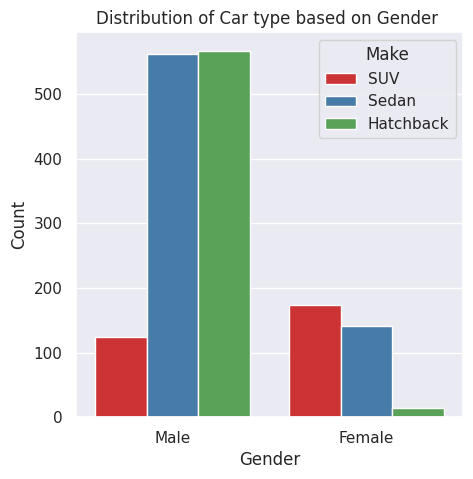

In [86]:
#plotting countplot.
plt.figure(figsize=(5,5))
plt.title('Distribution of Car type based on Gender ')
sns.countplot(data=austo_data,x='Gender',hue='Make',palette='Set1')
plt.ylabel('Count')
plt.xlabel('Gender')
plt.show()

In [87]:
#Counts of different car model prefered based on gender.
austo_data.groupby("Gender")["Make"].value_counts(normalize=True).reset_index(name='Proportion')

,Gender,Make,Proportion
0,Female,SUV,0.525836
1,Female,Sedan,0.428571
2,Female,Hatchback,0.045593
3,Male,Hatchback,0.452875
4,Male,Sedan,0.448083
5,Male,SUV,0.099042


* The plot suggests that males prefer Sedans(44.8%) and Hatchbacks(45.3%) style cars probably due to affordability, but have low preference for SUVs(9.9%).
* Females are purchasing more SUVs(52.6%), followed by Sedans(42.9%), less interest for Hatchbacks(4.6%), this is because females have high income as compared to males and, they are able to afford the premium models.
* Thus we can say SUVs are more preferred by females than males.


### **Observations on Profession and Make to find out if certain professionals like certain car models.**

Profession vs Make Sedan Preference Plot

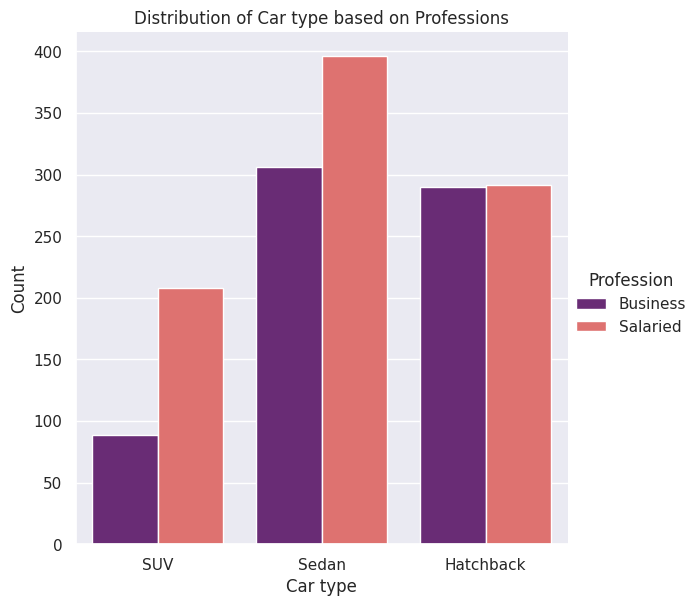

In [88]:
#plotting count tplot.
sns.catplot(data=austo_data,x='Make',hue='Profession',kind='count',palette='magma',height=6)
plt.title('Distribution of Car type based on Professions')
plt.xlabel('Car type')
plt.ylabel('Count')
plt.show()

In [89]:
#Counts of different car model prefered based on Profession.
austo_data.groupby("Profession")["Make"].value_counts(normalize=True).reset_index(name='Proportion')

,Profession,Make,Proportion
0,Business,Sedan,0.446715
1,Business,Hatchback,0.423358
2,Business,SUV,0.129927
3,Salaried,Sedan,0.441964
4,Salaried,Hatchback,0.325893
5,Salaried,SUV,0.232143


* The plot highlights that business professional prefer Sedans(44.8%) and Hatchbacks(42.3%) style cars over SUVs(12.99%),probably due to cost-efficiency.
* Salaried individuals are purchasing more SUVs(23.21%) as compared to Sedans(44.2%), followed by Hatchbacks(32.6%).
* Thus, we can say SUVs are more preferred by Salaried professional than business professionals. This could be because Salaried professionals income is slightly more than business professionals.
* Salaried professionals are slightly less likely to choose Sedans than business professionals, as Sedans aligns with family needs and stable income.
* However, Sedans are still most preferred cars among both the groups.



### **Observations on Gender and Marital_status columns to examine distribution of marital status across genders.**

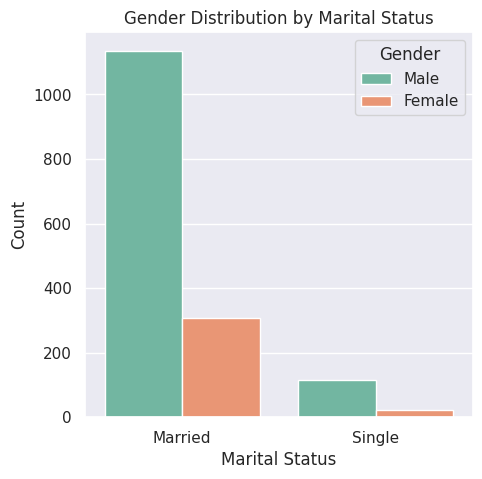

In [90]:
#plotting countplot.
plt.figure(figsize=(5,5))
plt.title('Gender Distribution by Marital Status')
sns.countplot(data=austo_data,x='Marital_status',hue='Gender',palette='Set2')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

In [91]:
#Creating a cross tab to analyse how many males and females are married (1) or single(0).
pd.crosstab(austo_data['Gender'],austo_data['Marital_status']).reset_index()


Marital_status,Gender,Married,Single
0,Female,307,22
1,Male,1136,116


* The data from the plot indicates there are slightly more females(307/329 = ~93.3%) than married males(1136/1252 = ~90.7%).
* There is a 10yo age gap between female and males as per dataset, that explains slightly higher marriage rate among females.
* However, there less single females(22/329 = ~6.7% ) than males(116/1252 = ~9.3%).
* Since, males dominates both category shows skewed gender ratio.



### **Observations on Partner_working and Make columns to examine if working partner influence high-priced car purchases.**

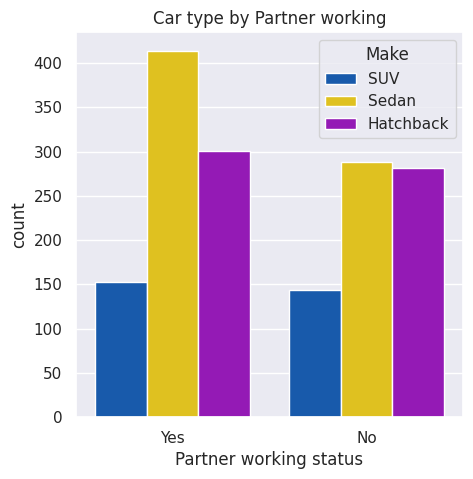

In [92]:
#plotting countplot.
plt.figure(figsize=(5,5))
plt.title('Car type by Partner working')
sns.countplot(data=austo_data,x='Partner_working',hue='Make',palette='prism')
plt.xlabel('Partner working status')
plt.show()

In [93]:
austo_data.groupby('Partner_working')['Make'].value_counts(normalize=True).reset_index(name='Proportion')

,Partner_working,Make,Proportion
0,No,Sedan,0.403927
1,No,Hatchback,0.394109
2,No,SUV,0.201964
3,Yes,Sedan,0.476959
4,Yes,Hatchback,0.346774
5,Yes,SUV,0.176267


* From the graph it is evident that working partner tends to purchase Sedans(47.7%), followed by Hatchbacks(34.7%) and with least purchase of SUVs(17.62%).
* Non-working partners tends to buy Sedans(40.4%), followed by Hatchbacks(39.41%),but have minimum interest to purchase SUVs(20.2%).
* This indicates, working partners tends to purchase SUVs slightly more than non-working partners. Thus, having a working partner does not significantly influence high-priced car purchases.



### **Observations on Partner_working and Personal_loan columns to evaluate whether dual income family take personal loans.**

Partner_working   No  Yes
Personal_loan            
No               348  441
Yes              365  427




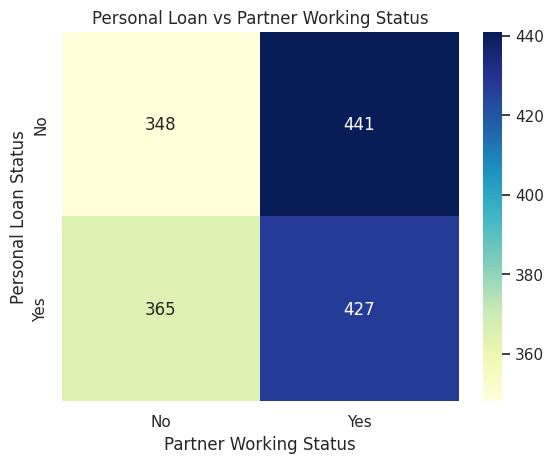

In [94]:
cross_tab = pd.crosstab(austo_data['Personal_loan'], austo_data['Partner_working'])
print(cross_tab)
print('\n')
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Personal Loan vs Partner Working Status')
plt.xlabel('Partner Working Status')
plt.ylabel('Personal Loan Status')
plt.show()

* Heatmap data shows there are more customers(441) with working partners and who took loans are 427 and who did not are 441.
* Thus, customers with working partners(dual-income family) are not significantly more or less likely to take personal loan compared to customers with non-working partners.


### **Observations on Gender and Education columns to see whether education level varies based on gender.**

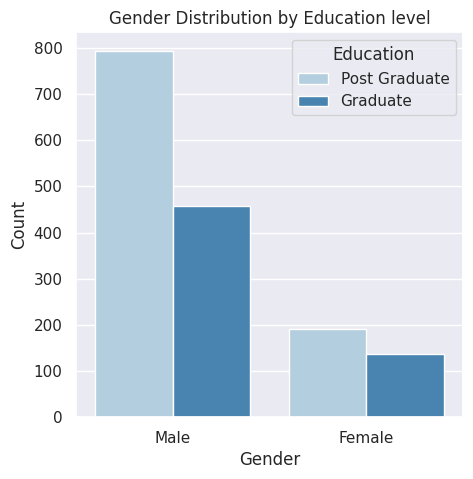

In [95]:
#plotting countplot.
plt.figure(figsize=(5,5))
plt.title('Gender Distribution by Education level')
sns.countplot(data=austo_data,x='Gender',hue='Education',palette='Blues')
plt.ylabel('Count')
plt.xlabel('Gender')
plt.show()

In [96]:
austo_data.groupby('Education')['Gender'].value_counts(normalize=True).unstack()

Gender,Female,Male
Education,,
Graduate,0.231544,0.768456
Post Graduate,0.193909,0.806091


* The count plot shows there are there are more male graduates as compared to females.
* There are 23.15% female graduates and 76.84% of male graduates. Thus, there are more male graduates than females.
* Likewise, there are 19.4% feamle post graduates and 80.60% of male post graduates. Thus, there are more male post graduates than females.
* Overall, males have higher education level than females.
* However, gender based education level does not significantly influence salary as females still tends to be the high earner.


# **MULTIVARIATE ANALYSIS**

## **Obervations on Profession, Gender and Make columns to find out if salaried male is an easier target for a SUV sale over a Sedan sale.**

In [97]:
#Finding salaried males
salaried_males = austo_data[(austo_data['Gender']=='Male')&(austo_data['Profession']=='Salaried')]
print("Total salaried males:")
print(salaried_males[['Profession','Gender']].value_counts().reset_index(name='count'))

Total salaried males:
  Profession Gender  count
0   Salaried   Male    672


* Total Salaried males are 672.

In [98]:
#Finding salaried males who prefer SUVs.
salaried_males_SUV = salaried_males['Make'].value_counts().reset_index(name='count')
print("Salaried males who prefer SUVs:")
print(salaried_males_SUV)


Salaried males who prefer SUVs:
        Make  count
0      Sedan    305
1  Hatchback    277
2        SUV     90


* Salaried males who prefer SUVs(90) over Sedans(305).

In [99]:
# Group by Gender, Profession, and Make
group1 = austo_data.groupby(['Gender', 'Profession', 'Make']).size().reset_index(name='Count')
salaried_females = group1[(group1['Gender'] == 'Female')&(group1['Profession'] == 'Salaried')]
print("Salaried females:")
print(salaried_females)

Salaried females:
   Gender Profession       Make  Count
2  Female   Salaried  Hatchback     15
3  Female   Salaried        SUV    118
4  Female   Salaried      Sedan     91


* In comparison to males, more salaried females(118) prefer SUVs over Sedans(91).

Profession vs Gender vs Make Plot

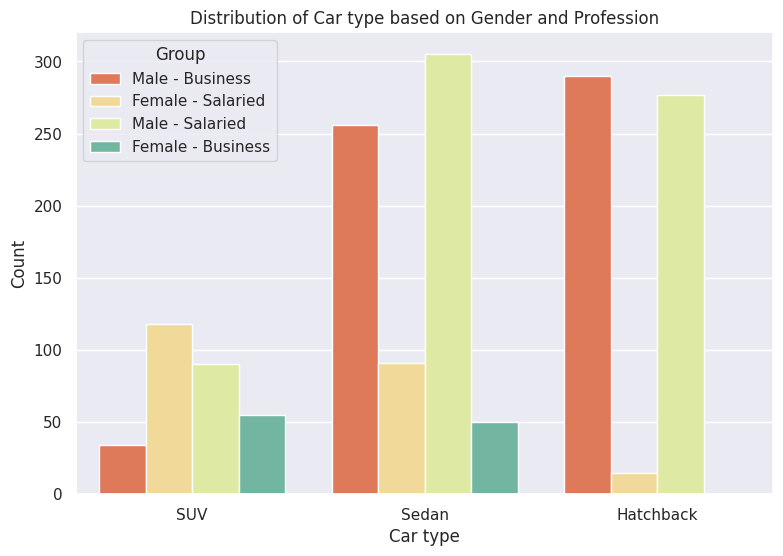

In [100]:
#count plot
austo_data['Group'] = austo_data['Gender'] + ' - ' + austo_data['Profession']
plt.figure(figsize=(9, 6))
sns.countplot(data=austo_data, x='Make', hue='Group', palette='Spectral')
plt.title('Distribution of Car type based on Gender and Profession')
plt.xlabel('Car type')
plt.ylabel('Count')
plt.show()



* The bar plot illustrates Salaried males who prefer SUVs are 90 and 305 salaried males prefer Sedans.
* Thus, Sedans are most preferred car among salaried males.
* Therefore, salaried males are not easier target for a SUV sales over Sedans.
* As per data, salaried females are easier target for SUV sales, as total of 118 salaried females preferred SUVs.
* Sedans could be easier target for salaried males, as total of 305 salaried males showed preference for Sedans.
* Although, in comparison to males, more salaried females(118) prefer SUVs over Sedans(91).

# **KEY QUESTIONS**

## **Q1. Do men tend to prefer SUVs more compared to women?**

* [See the Gender vs Make SUV Preference Plot](#scrollTo=Mxc02zOzZL0u&line=3&uniqifier=1)
* [See the associated data](#scrollTo=9bUKnU-SaOQN&line=2&uniqifier=1)
* There are 44.8% males prefer Sedans(44.8%) and only 9.9% prefer for SUVs cars probably due to affordability.
* 52.6 % Females purchased SUVs(52.6%), this could be because females have high income as compared to males and, they are able to afford the premium models.
* Thus, women tend prefer SUVs than males.
* So, no men do not tend to prefer SUVs compared to women.





## **Q2. What is the likelihood of a salaried person buying a Sedan?**

* [See the Profession vs Make Sedan Preference Plot](#scrollTo=hj_Z914Uh4og&line=4&uniqifier=1)
* [See the associated data](#scrollTo=pPiTjanoi9Om&line=1&uniqifier=1)
* There are 44.8% business professional who prefers Sedans(44.8%)cars over SUVs, probably due to cost-efficiency.
* 44.2% Salaried individuals are purchasing Sedans as compared to SUVs.
* SUVs are more preferred by Salaried professional than business professionals. This could be because Salaried professionals income is slightly more than business professionals.
* Salaried professionals are slightly less likely to choose Sedans, as Sedans aligns with family needs and stable income.


## **Q3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?**

* [See the Profession vs Gender vs Make Plot](#scrollTo=TWU4rXPMgwtn&line=3&uniqifier=1)
* [See associated data1](#scrollTo=phYgHjMHTEMx&line=3&uniqifier=1)
*[See the associated data2](#scrollTo=wgcPkxdiVFym&line=3&uniqifier=1)
* Salaried males who prefer SUVs are 90 and 305 salaried males prefer Sedans.
* Thus, Sedans are most preferred car among salaried males.
* Therefore, salaried males are not easier target for a SUV sales over Sedans.
* As per data, salaried females are easier target for SUV sales, as total of 118 salaried females preferred SUVs.
* So, the claim made by Sheldon Cooper is incorrect.

## **Q4. How does the the amount spent on purchasing automobiles vary by gender?**

* [See the Gender vs Price Plot](#scrollTo=ym9JWJV6PfHS&line=3&uniqifier=1)
* [See the associated data](#scrollTo=VqrXCP82nd1T&line=2&uniqifier=1)
* Average average amount spent by females is around 48k while for males it is around 32k. Median purchase price for males is 29k while for female is 49k.
* Thus, Female customers are spending more than males by mean and median.
* Total amount spent to purchase an automobile by female is 15695000 and for males is 40585000.
* Even though females have higher per person spending but total purchase volume is more for males.
* Thus, we can conclude that female tend to spend more per automobile purchase, males have the larger purchasing volume, contributing more to the revenue than females.

## **Q5. How much money was spent on purchasing automobiles by individuals who took a personal loan?**

* [See the Personal_loan vs Price Plot](#scrollTo=6ZG5H0o5mrLg&line=4&uniqifier=1)
* [See the associated data](#scrollTo=jSNLydCRsvgF&line=2&uniqifier=1)
* Average price for people having no personal loan is approximately 37k, while for those with loan is around 34k, indicating non-loan buyers spend more per transaction.
* Total amount spent by 792 individuals who took personal loan to purchase automobile is 27290000, while 789 individuals without loan is 28990000.
* Even though customers without loan were less in number, their total spent is still nearly equal.
* This indicates person without loan spends more money on an average than those with loan, also person without loan spent more per person than those with loan.
* Thus, we can say, individuals without personal loans are purchasing more expensive cars as compared to those with loans, suggesting that people prioritise spending loan amount on important things than luxury.


## **Q6. How does having a working partner influence the purchase of higher-priced cars?**

* [See the  Partner_working vs Price Plot](#scrollTo=0JGvkEwuK0q-&line=4&uniqifier=1)
* [See the associated data](#scrollTo=FDFwgmzoODPM&line=3&uniqifier=1)
* Median purchase price for working partner and non-working partner is 31k.
* Average purchase price of working partner is 35267.28k while for non-working partner is 36k.
* Working partners made more car purchases(868) while non-working partner made total of 713 purchases.
* This indicates having a working partner does not significantly influence the purchase of high priced cars, as the difference in average purchase price is marginal i.e. 1k. This could be due to income stability of working partners.

# **ACTIONABLE INSIGHTS & RECOMMENDATIONS**

## **Insights**

**We have analysed Austo Motor Company data and our analyses reveals cutomers demands by understanding their purchasing patterns, behaviours and preferences. This will help the business to strategize marketing campaigns to tailored to different groups of customer thereby enhancing their overall customer experience.**




Based on the analysis we conclude:

***Customer Groups & Preferences:***
*  High income females( average salary 66k) prefer SUVs(~52% of purchases) and spend more per transaction than males.
*  Salaried professionals prefer SUVs(23.2%) over business professionals, likely due to stable income.
*  Personal Loan holders opt inexpensive cars(average 34k vs 37k for non-loan buyers), as they prioritise affordability over luxury.

***Price-Conscious:***
*  Hatchbacks are most preferred among budget-conscious families(avg. 26k) and those with more dependants.
*  SUVs are most preferred among wealthy family (avg. total salary 96k), sees SUVs as status symbols.

***Demographic Trend:***
*  Older customers(35+) earn more (avg. 72k-82k) and prefer high-end models.
* Married females (93.3% of females) purchase more SUVs than married males(~90%).
* Males dominate higher education levels, but females earn more.

***Financial-Influence:***
*  Dual-income household (partner is working) buy more frequently but not more expensively (avg. 35k), prioritise practicality over luxury.
*  House loan holders spend 10% less on cars (median 29k) due to mortgage prioritisation.



















## **Business Recommendations**

***Targeted Marketing Campaigns:***

*   Advertise SUVs for high-income females by launching ads highlighting safety, luxury and status.
*   Promote Hatchbacks for budget conscious buyers highlight affordability and fuel efficiency to families with dependents.
*   Promote Sedans to Salaried Males by emphasizing on reliability and family-friendly features.
*   For older Customers(35+yrs) promote premium models(SUVs/Sedans) via retirement planning or family-focused campaigns.


***Product Strategy:***

*   Provide Premium Models for older customers by developing luxury sedan/SUV variants targeting customer aged 35+.
*   Provide flexible Financing for Loan Holder by offering low-interest loans or EMI plans for Hatchbacks/Sedans.

***Sales & Inventory:***

*   Prioritise SUVs in Wealthy Groups by stocking up SUVs for high income customers.
*   Target Sedans for Salaried Males by providing package deales on SUVs, including corporate or bank partnerships that offers employee or customer discounts.
*   Feature Sedans for Young professionals by prioritising Sedans for urban areas with younger professionals.

***Customer Experience:***

*   Offer family packages by giving more discounts on Hatchbacks for family having more than 3 dependants.
*   Launch Loyalty Programs by including reward points for each purchase, or offer 1st car servicing free for premium model car owners.












## **Future Analysis**

***Geographic Trends:***

*   Analyse customer base to determine whether Urban or rural and identify their preferred car models accordingly.
*   Assess car dealership success based on regional demographic,  revenue and their most sold car models.

***Loan Purpose:***

*   Survey customers to understand if the loan used for cars or other expenses(e.g. education/medical).

***Family Size Impact:***

*   Study how no. of dependants( 0-2 vs 3-4) influence car size vs. affordability trade-offs.

***Revenue Estimate:***

*   Analyse revenue generated by various customer groups based on location (urban vs. rural) and car model, to identify which segments contribute most to total revenue.

***Analyse Competitor Pricing:***
*   Compare Austo car pricing with competitors car pricing to identify the gaps and recommend adjustments.

***Operational Efficiency:***

*   *Dealer Performance:* Identify top-performing models by location (urban vs rural).
*   *Customer Retention:* Track repeat buyers car preference (e.g., sedan to SUV upgrades).











